<a href="https://colab.research.google.com/github/ELVINAFADHILARAMADANI/Probabilitas-Statistika/blob/main/Probabilitas_dan_Statistika_Elvina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== OUTPUT TABEL DATA ===
            ID                     Name  Marks in Quiz\n(Out of 100)  Mid Term Results (Out of 100)  Final Term Resul (Out of 100)  Final Score Grade
0   2455301219  Elvina Fadhila Ramadani                           80                             95                             98        91.25     A
1       120001                 John Doe                           85                             78                             90        84.44     A
2       120005               Jane Smith                           92                             88                             94        91.38     A
3       120017          Michael Johnson                           48                             65                             56        56.41     C
4       120018              Emily Brown                           90                             85                             88        87.65     A
5       120022          Daniel Martinez                           75      

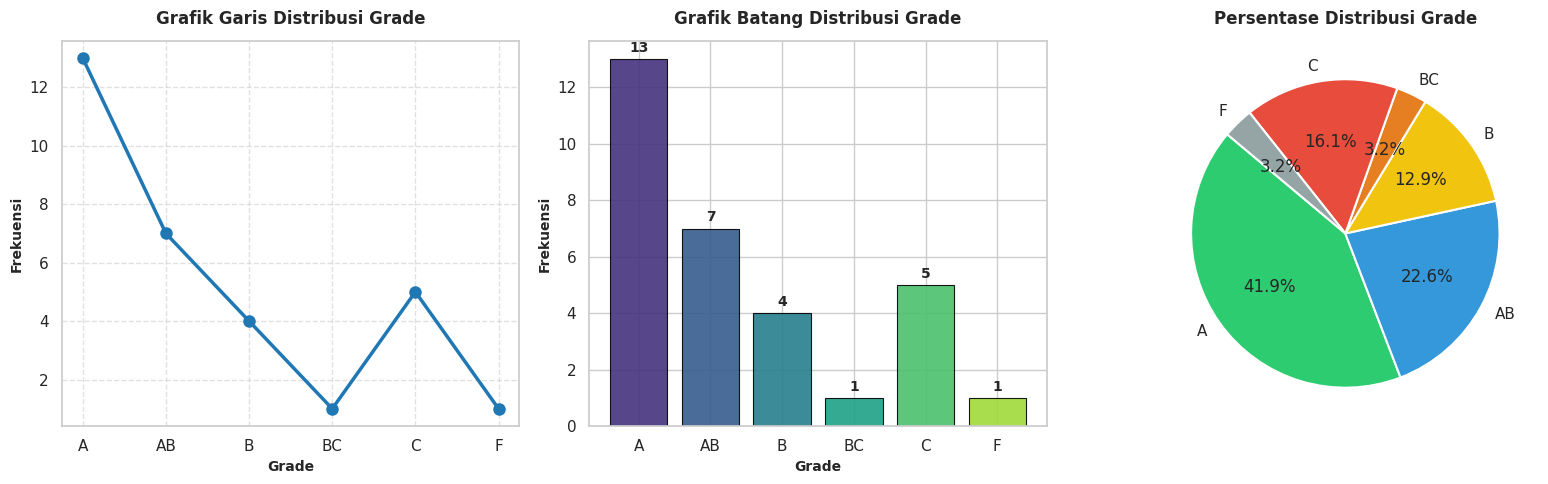

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
path = "Elvina.xlsx"
dataraw = pd.read_excel(path)

print("=== OUTPUT TABEL DATA ===")
print(dataraw.to_string())

datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
print("\n=== TABEL FREKUENSI GRADE ===")
print(datafrq)

dataraw["Final Score"] = pd.to_numeric(dataraw["Final Score"], errors='coerce')
dt = dataraw["Final Score"]

stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()

print("\n=== STATISTIKA DESKRIPTIF FINAL SCORE ===")
print(stats)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(datafrq.index, datafrq["Frekuensi"], marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
axes[0].set_title("Grafik Garis Distribusi Grade", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Grade", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Frekuensi", fontsize=10, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

palette = sns.color_palette("viridis", len(datafrq))
bars = axes[1].bar(datafrq.index, datafrq["Frekuensi"], color=palette, edgecolor='black', linewidth=0.8, alpha=0.9)
axes[1].set_title("Grafik Batang Distribusi Grade", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Grade", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Frekuensi", fontsize=10, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.15, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=10)

colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6']
axes[2].pie(datafrq["Frekuensi"], labels=datafrq.index, autopct='%1.1f%%', startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title("Persentase Distribusi Grade", fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()